# 4.41 The Package Mode on Paper

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs%2Ftut%2F4-Analysis%2F4.41-The-package-mode-on-paper.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2F4-Analysis%2F4.41-The-package-mode-on-paper.ipynb)

> 💡 **What you need.** Only NumPy, SciPy and matplotlib: this notebook is pure analysis, no mesher and no solver. It is the first of five that reproduce the paper by Molavi *et al.* [1] with open-source tools.

A superconducting processor sits in a metal box. The box is a microwave cavity, and its lowest modes can land right among the qubit frequencies. Every qubit then couples, weakly but measurably, to the same box mode — a channel for decay and for crosstalk between qubits that are nowhere near each other on the chip. Designing a large processor means knowing these couplings, qubit by qubit.

Molavi *et al.* [1] benchmark four ways of extracting them on a clean test case: a 10 × 10 array of transmons in a 30 × 30 × 3 mm box, half filled at the bottom by a silicon slab. This series reproduces their results with Quantum Metal, gmsh and scikit-fem:

| | Notebook | What it computes | Solver | Run time |
|---|---|---|---|---|
| 4.41 | [The package mode on paper](4.41-The-package-mode-on-paper.ipynb) | LSM modes, Fig. 11, the dipole estimate | analytic | seconds |
| 4.42 | [Four ways to measure a coupling](4.42-Four-ways-to-measure-a-coupling.ipynb) | the four methods on the two-mode circuit, the Appendix D fit | circuit algebra | seconds |
| 4.43 | [Mesh and solve the 10×10 processor](4.43-Mesh-and-solve-the-10x10-processor.ipynb) | the design in Quantum Metal, the mesh, the package eigenmode, qubit capacitance | gmsh + scikit-fem | ~5 min |
| 4.44 | [Every coupling from one eigenmode](4.44-Every-coupling-from-one-eigenmode.ipynb) | induced-EMF couplings of all 100 qubits, Figs. 6, 8, 9 | gmsh + scikit-fem | ~6 min |
| 4.45 | [Four methods, one full-wave model](4.45-Four-methods-one-full-wave-model.ipynb) | avoided crossing, EPR, induced EMF and impedance matrix side by side, Figs. 5, 7 | gmsh + scikit-fem | ~6 min |

This first notebook needs no simulation at all. The box and the slab alone set the package mode, and its fields can be written down in closed form (the paper's Appendix E). Those fields already predict the pattern of couplings across the array, and their size to within 10%.

**What you'll learn**

- why a silicon slab pulls the lowest box mode from 7.07 GHz down to 6.49 GHz, and what the mode looks like through the thickness of the box (Fig. 11 of the paper);
- why a qubit couples to the box through the *in-plane* field at the chip surface, not the vertical field that dominates the mode;
- how to estimate every qubit's coupling from its electric dipole moment, and what pattern that predicts across the array.

In [1]:
# In Colab, uncomment to install the dependencies of the whole series.
# !pip install -q "quantum-metal[skfem]" pymetis

In [2]:
import sys
import urllib.request
from pathlib import Path

# The solver code shared by tutorials 4.41-4.45 lives in docs/tut/resources/package_modes/.
RES = Path("../resources/package_modes")
if not (
    RES / "package_modes.py"
).exists():  # e.g. in Colab: fetch it next to the notebook
    RES = Path("package_modes")
    RES.mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/qiskit-community/qiskit-metal/main/"
        "docs/tut/resources/package_modes/package_modes.py",
        RES / "package_modes.py",
    )
sys.path.insert(0, str(RES))

import package_modes as pm

import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c as C0, epsilon_0 as EPS0

## 1. The device

The validation device of the paper (its Fig. 4): a perfectly conducting box, a silicon slab on its floor, and 100 bare transmons on the silicon — each two rectangular paddles with a Josephson junction across the gap between them. There is no ground plane on the chip, which makes every coupling larger than in a real processor and easier to compute.

In [3]:
d = pm.DEVICE
for key, value in d.items():
    print(f"{key:>6} = {value}")

    Lx = 30.0
    Ly = 30.0
    Lz = 3.0
     t = 0.5
 eps_r = 11.9
     n = 10
 pitch = 3.0
 pad_w = 0.5
 pad_h = 1.0
   gap = 0.2


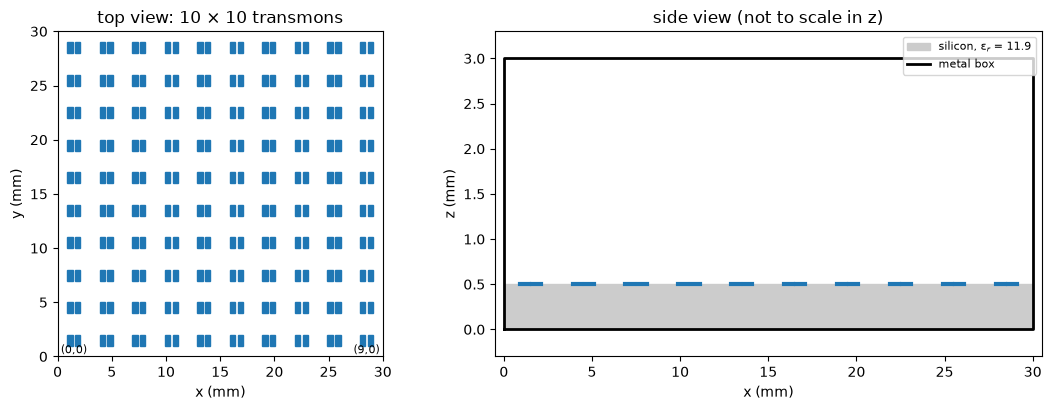

In [4]:
fig, (top, side) = plt.subplots(
    1, 2, figsize=(11, 4.2), gridspec_kw=dict(width_ratios=[1, 1.35])
)

# top view: the array
for (i, j), (x, y) in pm.qubit_centers().items():
    for sign in (-1, 1):
        x0 = x + sign * (d["gap"] / 2 + d["pad_w"] / 2) - d["pad_w"] / 2
        top.add_patch(
            plt.Rectangle(
                (x0, y - d["pad_h"] / 2), d["pad_w"], d["pad_h"], color="tab:blue"
            )
        )
top.set(
    xlim=(0, d["Lx"]),
    ylim=(0, d["Ly"]),
    aspect="equal",
    xlabel="x (mm)",
    ylabel="y (mm)",
    title="top view: 10 × 10 transmons",
)
top.text(1.5, 1.5 - 1.2, "(0,0)", ha="center", fontsize=8)
top.text(28.5, 1.5 - 1.2, "(9,0)", ha="center", fontsize=8)

# side view: box, slab, paddles
side.add_patch(
    plt.Rectangle((0, 0), d["Lx"], d["t"], color="0.8", label="silicon, ε$_r$ = 11.9")
)
side.plot(
    [0, d["Lx"], d["Lx"], 0, 0],
    [0, 0, d["Lz"], d["Lz"], 0],
    "k",
    lw=2,
    label="metal box",
)
for (i, j), (x, y) in pm.qubit_centers().items():
    if j == 0:
        for sign in (-1, 1):
            xc = x + sign * (d["gap"] + d["pad_w"]) / 2
            side.plot(
                [xc - d["pad_w"] / 2, xc + d["pad_w"] / 2],
                [d["t"], d["t"]],
                color="tab:blue",
                lw=3,
            )
side.set(
    xlim=(-0.5, d["Lx"] + 0.5),
    ylim=(-0.3, d["Lz"] + 0.3),
    xlabel="x (mm)",
    ylabel="z (mm)",
    title="side view (not to scale in z)",
)
side.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 2. The empty box

Without the slab, the lowest mode of a box with $L_z < L_x, L_y$ is $\mathrm{TM}_{110}$. Its electric field points straight up and has the shape of the lowest drum mode,

$$E_z = E_0 \sin(\pi x/L_x)\,\sin(\pi y/L_y), \qquad f_{110} = \frac{c}{2}\sqrt{L_x^{-2}+L_y^{-2}} .$$

In [5]:
f_empty = C0 / 2 * np.hypot(1 / (d["Lx"] * 1e-3), 1 / (d["Ly"] * 1e-3))
print(
    f"empty box, TM110: {f_empty / 1e9:.3f} GHz   (paper: {pm.PAPER['f_empty'] / 1e9:.2f} GHz)"
)

empty box, TM110: 7.066 GHz   (paper: 7.07 GHz)


## 3. Add the slab: the LSM$_{110}$ mode

The silicon changes two things. The field now crosses an interface where the permittivity jumps by 11.9, and the mode slows down: some of its energy sits in a region where light is 3.4 times slower. The mode that grows out of $\mathrm{TM}_{110}$ keeps the same in-plane shape, $\sin(\pi x/L_x)\sin(\pi y/L_y)$, and gains a vertical profile — a cosine in the silicon and a hyperbolic cosine in the vacuum above it:

$$E_z^{\rm Si} = E_{0,z}\cos(k_z^{\rm Si} z), \qquad
E_z^{\rm air} = \varepsilon_r E_{0,z}\,\frac{\cos(k_z^{\rm Si} t)}{\cosh\!\big(k_z^{\rm air}(L_z-t)\big)}\,\cosh\!\big(k_z^{\rm air}(L_z-z)\big) .$$

The factor $\varepsilon_r$ makes the vertical *displacement* field $D_z$ continuous across the interface. Requiring the in-plane field to be continuous too fixes the frequency, through the transcendental equation (E3) of the paper,

$$k_z^{\rm Si}\tan(k_z^{\rm Si} t) = \varepsilon_r k_z^{\rm air}\tanh\!\big(k_z^{\rm air}(L_z-t)\big), \quad
k_z^{\rm Si}=\sqrt{\varepsilon_r k_0^2-\gamma^2},\quad k_z^{\rm air}=\sqrt{\gamma^2-k_0^2},$$

with $k_0 = \omega/c$ and $\gamma^2 = (\pi/L_x)^2 + (\pi/L_y)^2$. The mode has $H_z = 0$ everywhere: a *longitudinal-section magnetic* (LSM) mode [3]. `pm.lsm_mode` solves (E3) with a bracketing root finder; the cell below shows the function whose root it finds.

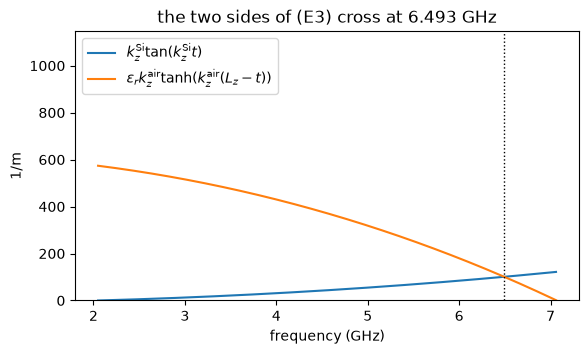

In [6]:
mode = pm.lsm_mode(1, 1)

t, Lz, er = mode.t, mode.Lz, mode.eps_r
f = np.linspace(
    C0 * mode.gamma / np.sqrt(er) / (2 * np.pi) * 1.001,
    C0 * mode.gamma / (2 * np.pi) * 0.999,
    800,
)
k0 = 2 * np.pi * f / C0
ks, ka = np.sqrt(er * k0**2 - mode.gamma**2), np.sqrt(mode.gamma**2 - k0**2)
lhs, rhs = ks * np.tan(ks * t), er * ka * np.tanh(ka * (Lz - t))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(f / 1e9, lhs, label=r"$k_z^{\rm Si}\tan(k_z^{\rm Si} t)$")
ax.plot(f / 1e9, rhs, label=r"$\varepsilon_r k_z^{\rm air}\tanh(k_z^{\rm air}(L_z-t))$")
ax.axvline(mode.f / 1e9, color="k", ls=":", lw=1)
ax.set(
    xlabel="frequency (GHz)",
    ylabel="1/m",
    ylim=(0, 2 * rhs.max()),
    title=f"the two sides of (E3) cross at {mode.f / 1e9:.3f} GHz",
)
ax.legend()
plt.show()

In [7]:
approx = pm.lsm_mode_approx(1, 1)
P = pm.PAPER
rows = [
    ("f_110 (GHz)", mode.f / 1e9, approx["f"] / 1e9, P["f_si"] / 1e9),
    ("k_z Si (1/m)", mode.kz_si, approx["kz_si"], P["kz_si"]),
    ("k_z air (1/m)", mode.kz_air, approx["kz_air"], P["kz_air"]),
    ("E0x for 1 J (MV/m)", mode.E0x / 1e6, approx["E0x"] / 1e6, P["E0x_110"] / 1e6),
]
print(f"{'':>20} {'exact (E3)':>11} {'closed form':>12} {'paper':>8}")
for name, a, b, p in rows:
    print(f"{name:>20} {a:11.3f} {b:12.3f} {p:8.3f}")

                      exact (E3)  closed form    paper
         f_110 (GHz)       6.493        6.504    6.490
        k_z Si (1/m)     445.447      446.340  445.400
       k_z air (1/m)      58.440       57.864   58.400
  E0x for 1 J (MV/m)      25.561       25.116   25.560


The closed-form column uses the approximations at the end of Appendix E, valid because $k_z t$ and $k_z^{\rm air}(L_z-t)$ are small (0.22 and 0.15): the slab and the vacuum act like two capacitors in series, with an effective permittivity $\varepsilon_{\rm eff} = [\varepsilon_r^{-1}(t/L_z) + (1-t/L_z)]^{-1} \approx 1.18$, and $f \approx f_{\rm empty}/\sqrt{\varepsilon_{\rm eff}}$.

## 4. The mode through the thickness (Fig. 11)

Because $k_z$ is small in both layers, the fields barely vary with height: the displacement field $D_z$ is nearly uniform from floor to lid, and $E_z$ is 11.9 times larger in the vacuum than in the silicon.

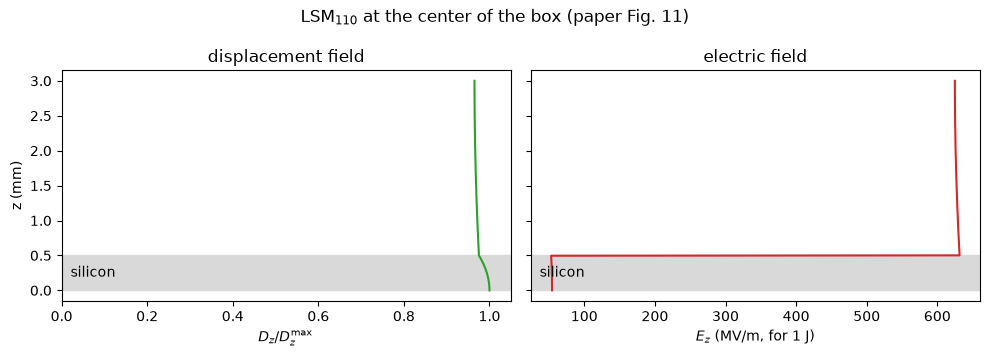

E_z jumps by 11.90 at the silicon surface


In [8]:
z = np.linspace(0, Lz, 600)
Ez = mode.Ez(z)
Dz = np.where(z <= t, er, 1.0) * EPS0 * Ez

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
ax[0].plot(Dz / Dz.max(), z * 1e3, color="tab:green")
ax[0].set(
    xlabel=r"$D_z / D_z^{\max}$",
    ylabel="z (mm)",
    title="displacement field",
    xlim=(0, 1.05),
)
ax[1].plot(Ez / 1e6, z * 1e3, color="tab:red")
ax[1].set(xlabel=r"$E_z$ (MV/m, for 1 J)", title="electric field")
for a in ax:
    a.axhspan(0, t * 1e3, color="0.85", zorder=0)
    a.text(0.02, t * 1e3 / 2, "silicon", transform=a.get_yaxis_transform(), va="center")
plt.suptitle("LSM$_{110}$ at the center of the box (paper Fig. 11)")
plt.tight_layout()
plt.show()
print(
    f"E_z jumps by {mode.Ez(t + 1e-12) / mode.Ez(t - 1e-12):.2f} at the silicon surface"
)

## 5. What the qubits feel: the in-plane field

A transmon's two paddles sit flat on the silicon, side by side along $x$. In the qubit mode their charges are equal and opposite, so the qubit is a small electric dipole pointing along $x$, and it responds to $E_x$ — not to $E_z$, which pushes both paddles the same way.

In an empty box $\mathrm{TM}_{110}$ has no $E_x$ at all. The slab creates one. The field lines of $E_z$ bend at the interface, and at the silicon surface the mode acquires (Eqs. E7, E8)

$$E_x\big|_{z=t} = a\,E_{0,x}\cos(a\pi x/L_x)\,\sin(b\pi y/L_y), \qquad E_x = \gamma^{-2}\,\partial_x\partial_z E_z ,$$

with $E_{0,x} = -E_{0,z}(\pi/L_x)\,k_z^{\rm Si}\sin(k_z^{\rm Si}t)/\gamma^2$ (Eq. E9) — negative where $E_z > 0$, because $E_z$ falls with height in the silicon. The paper quotes its magnitude, and so does `mode.E0x`. The field is proportional to $\partial_x E_z$: it vanishes where $E_z$ peaks, at the center of the box, and is largest along the walls $x = 0$ and $x = L_x$, with opposite signs on the two sides.

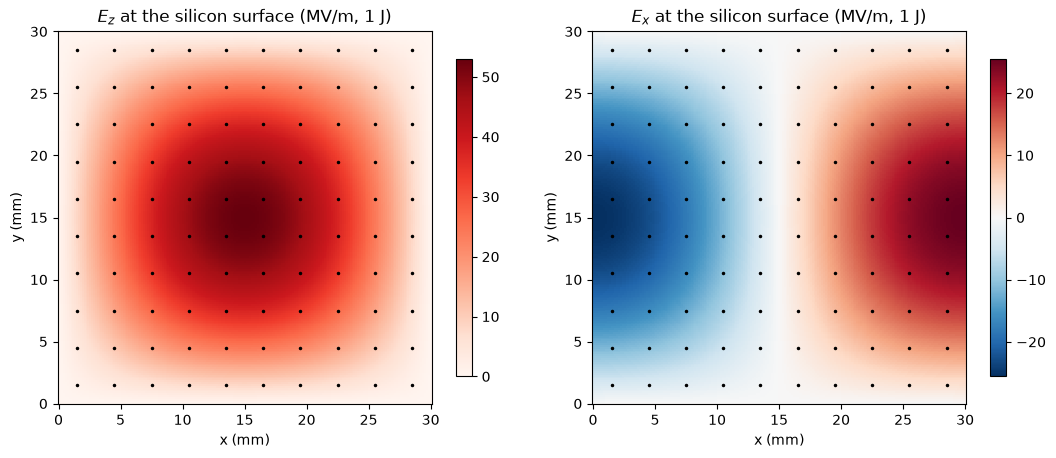

In [9]:
x = np.linspace(0, mode.Lx, 201)
y = np.linspace(0, mode.Ly, 201)
X, Y = np.meshgrid(x, y)
Ez_top = (
    mode.Ez(np.array([t]))[0]
    * np.sin(np.pi * X / mode.Lx)
    * np.sin(np.pi * Y / mode.Ly)
)
Ex_top = mode.Ex_surface(X, Y)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for a, F, name, cmap in (
    (ax[0], Ez_top, "$E_z$", "Reds"),
    (ax[1], Ex_top, "$E_x$", "RdBu_r"),
):
    lim = np.abs(F).max() / 1e6
    im = a.pcolormesh(
        X * 1e3,
        Y * 1e3,
        F / 1e6,
        cmap=cmap,
        vmin=-lim if cmap == "RdBu_r" else 0,
        vmax=lim,
        shading="auto",
    )
    xs = [q[0] for q in pm.qubit_centers().values()]
    ys = [q[1] for q in pm.qubit_centers().values()]
    a.plot(xs, ys, "k.", ms=3)
    a.set(
        aspect="equal",
        xlabel="x (mm)",
        ylabel="y (mm)",
        title=f"{name} at the silicon surface (MV/m, 1 J)",
    )
    plt.colorbar(im, ax=a, shrink=0.85)
plt.tight_layout()
plt.show()

## 6. The electric-dipole estimate of every coupling

Treat each qubit as a dipole $p_x$ in the field $E_x$ of the package mode. The interaction energy $p_x E_x$, with both mode energies set to 1 J and rms instead of peak amplitudes, gives the capacitive coupling efficiency (Eq. 16 of the paper)

$$k_C(x,y) = \frac{p_x\,E_x|_{z=t}(x,y)}{2\sqrt{E_m E_n}}, \qquad g = \tfrac12 k_C\,\omega_m \ \text{on resonance}.$$

The paper takes $p_x = 3.41\times10^{-10}$ C·m for a qubit with 1 J of energy from its HFSS eigenmode (notebook 4.43 computes it with our own electrostatics). Then every coupling follows the single pattern

$$g(x, y) = A\,\cos(\pi x/L_x)\,\sin(\pi y/L_y).$$

In [10]:
kC, A = pm.dipole_coupling(P["px"], mode)
print(f"k_C at the field maximum = {kC:.3e}")
print(
    f"A/2pi = {A / 1e6:.2f} MHz   (paper, dipole estimate: {P['A_110_dipole'] / 1e6:.1f} MHz;"
    f" full-wave fit: {P['A_110'] / 1e6:.1f} MHz)"
)

k_C at the field maximum = 4.358e-03
A/2pi = 14.15 MHz   (paper, dipole estimate: 14.2 MHz; full-wave fit: 15.6 MHz)


The prediction for the array: couplings antisymmetric about the middle column, largest in the outer columns and toward the middle rows, and — because the dipoles point along $x$ — a different pattern along $x$ than along $y$. Notebook 4.44 compares this map with the full-wave result.

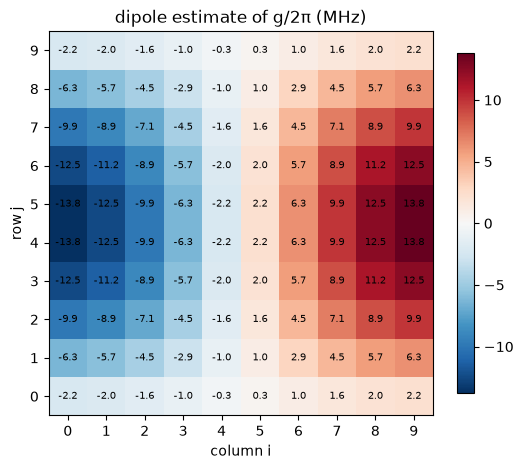

In [11]:
g_pred = np.zeros((10, 10))
for (i, j), (xq, yq) in pm.qubit_centers().items():
    g_pred[j, i] = (
        A * mode.Ex_surface(xq * 1e-3, yq * 1e-3) / mode.E0x
    )  # the sign of g follows E_x

fig, ax = plt.subplots(figsize=(6.2, 5.2))
lim = np.abs(g_pred).max() / 1e6
im = ax.imshow(g_pred / 1e6, origin="lower", cmap="RdBu_r", vmin=-lim, vmax=lim)
for i, j in pm.qubit_centers():
    ax.text(i, j, f"{g_pred[j, i] / 1e6:.1f}", ha="center", va="center", fontsize=7)
ax.set(
    xlabel="column i",
    ylabel="row j",
    title="dipole estimate of g/2π (MHz)",
    xticks=range(10),
    yticks=range(10),
)
plt.colorbar(im, ax=ax, shrink=0.85)
plt.show()

### The second mode: LSM$_{210}$

The same reasoning applies to every LSM$_{ab0}$ mode. For LSM$_{210}$ the in-plane field carries an extra factor $a = 2$, the frequency is higher, and $E_{0,x}$ is nearly unchanged, so the model predicts a coupling amplitude larger by about $2\,\omega_{210}/\omega_{110}$.

In [12]:
mode2 = pm.lsm_mode(2, 1)
kC2, A2 = pm.dipole_coupling(P["px"], mode2)
print(
    f"LSM210: f = {mode2.f / 1e9:.2f} GHz (paper {P['f_lsm210'] / 1e9:.2f}),"
    f" E0x = {mode2.E0x / 1e6:.2f} MV/m (paper {P['E0x_210'] / 1e6:.2f})"
)
print(
    f"A_210/2pi = {A2 / 1e6:.1f} MHz (paper, dipole estimate: {P['A_210_dipole'] / 1e6:.1f} MHz)"
)
print(f"A_210/A_110 = {A2 / A:.3f};   2 w_210 / w_110 = {2 * mode2.f / mode.f:.3f}")

LSM210: f = 10.24 GHz (paper 10.23), E0x = 26.25 MV/m (paper 26.25)
A_210/2pi = 45.8 MHz (paper, dipole estimate: 45.7 MHz)
A_210/A_110 = 3.238;   2 w_210 / w_110 = 3.153


## Summary

| Quantity | This notebook | Paper |
|---|---|---|
| empty box, TM$_{110}$ | 7.07 GHz | 7.07 GHz |
| with silicon, LSM$_{110}$ | 6.49 GHz | 6.49 GHz |
| $k_z^{\rm Si}$, $k_z^{\rm air}$ | 445.4, 58.4 m$^{-1}$ | 445.4, 58.4 m$^{-1}$ |
| $E_{0,x}$ (1 J) | 25.56 MV/m | 25.56 MV/m |
| dipole estimate of $A/2\pi$ | 14.2 MHz | 14.2 MHz |
| dipole estimate of $A_{210}/2\pi$ | 45.8 MHz | 45.7 MHz |

The whole coupling map rests on one mechanism: the slab tilts the package field at the chip surface, and each transmon's dipole picks up the tilt.

## Where to go next

- **4.42 Four ways to measure a coupling** — the four extraction methods of the paper, first on a two-mode circuit where every answer is known exactly.
- **4.43 Mesh and solve the 10 × 10 processor** — the same box, now with the paddles, as a Quantum Metal design meshed with gmsh and solved with a finite-element Maxwell solver.
- Change the slab thickness in `pm.lsm_mode(1, 1, t=0.25)` and watch $E_{0,x}$ — and with it every coupling — scale almost linearly with $t$ (Eq. E15).

## References

1. R. Molavi, E. Forati, Y. Zhang, A. R. Klots, J. Atalaya, B. W. Langley, D. A. Timucin, M. Nazari, G. Khan, Z. K. Minev, A. N. Korotkov, M. H. Devoret, "Extracting electromagnetic bare mode couplings in large superconducting quantum processors," [arXiv:2609.22442](https://arxiv.org/abs/2609.22442) (2026).
2. Z. K. Minev, Z. Leghtas, S. O. Mundhada, L. Christakis, I. M. Pop, M. H. Devoret, "Energy-participation quantization of Josephson circuits," *npj Quantum Inf.* **7**, 131 (2021). [doi:10.1038/s41534-021-00461-8](https://doi.org/10.1038/s41534-021-00461-8)
3. C. A. Balanis, *Advanced Engineering Electromagnetics*, 2nd ed. (Wiley, 2012) — LSM modes of a partially filled waveguide.
4. C. Geuzaine, J.-F. Remacle, "Gmsh: A 3-D finite element mesh generator with built-in pre- and post-processing facilities," *Int. J. Numer. Methods Eng.* **79**, 1309–1331 (2009). [doi:10.1002/nme.2579](https://doi.org/10.1002/nme.2579)
5. T. Gustafsson, G. D. McBain, "scikit-fem: A Python package for finite element assembly," *J. Open Source Softw.* **5**, 2369 (2020). [doi:10.21105/joss.02369](https://doi.org/10.21105/joss.02369)